# Linear Regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Preprocessing of the dataset

In [2]:
#read the dataset
df = pd.read_csv("Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [5]:
df.describe(include="all")

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545,545,545,545,545,545.000000,545,545
unique,NaN,NaN,NaN,NaN,NaN,2,2,2,2,2,NaN,2,3
top,NaN,NaN,NaN,NaN,NaN,yes,no,no,no,no,NaN,no,semi-furnished
freq,NaN,NaN,NaN,NaN,NaN,468,448,354,520,373,NaN,417,227
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,NaN,NaN,NaN,NaN,NaN,0.693578,NaN,NaN
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,NaN,NaN,NaN,NaN,NaN,0.861586,NaN,NaN
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN


In [ ]:
#see all the datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


#### Numerical Features
- area
- bedrooms
- bathrooms
- stories
- parking

#### Boolean Features
- mainroad
- guestroom
- basement
- hotwaterheating
- airconditioning
- prefarea

In [ ]:
# see the number of missing values for each feature
df.isna().sum()
# the missing values for each feature is 0 so no imputation is needed

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

### Feature Encoding

In [9]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [10]:
# encode the cateogorical features
bool_cols = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

for col in bool_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

print(df.head())

      price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0  13300000  7420         4          2        3         1          0   
1  12250000  8960         4          4        4         1          0   
2  12250000  9960         3          2        2         1          0   
3  12215000  7500         4          2        2         1          0   
4  11410000  7420         4          1        2         1          1   

   basement  hotwaterheating  airconditioning  parking  prefarea  \
0         0                0                1        2         1   
1         0                0                1        3         0   
2         1                0                0        2         1   
3         1                0                1        3         1   
4         1                0                1        2         0   

  furnishingstatus  
0        furnished  
1        furnished  
2   semi-furnished  
3        furnished  
4        furnished  


In [11]:
# one hot encode furnishing status
df = pd.get_dummies(
    df,
    columns=['furnishingstatus'],
    drop_first=True
)
print(df.head())

      price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0  13300000  7420         4          2        3         1          0   
1  12250000  8960         4          4        4         1          0   
2  12250000  9960         3          2        2         1          0   
3  12215000  7500         4          2        2         1          0   
4  11410000  7420         4          1        2         1          1   

   basement  hotwaterheating  airconditioning  parking  prefarea  \
0         0                0                1        2         1   
1         0                0                1        3         0   
2         1                0                0        2         1   
3         1                0                1        3         1   
4         1                0                1        2         0   

   furnishingstatus_semi-furnished  furnishingstatus_unfurnished  
0                            False                         False  
1                       

### Split dataset

In [12]:
X = df.drop("price", axis=1)
y = df["price"]

### Create training and validation set

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Perform Feature Scaling on the numerical features

In [14]:
# we need to make the scalers on the training set only so that the distribution of the validation set is not leaked to the model
from sklearn.preprocessing import StandardScaler

num_cols = [
    'area',
    'bedrooms',
    'bathrooms',
    'stories',
    'parking'
]

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols]) # we transform the validation set data using the scaler that has been fit on the training set 
#this is done to avoid data leakage

In [16]:
print(X_train.head())
print(X_test.head())

         area  bedrooms  bathrooms   stories  mainroad  guestroom  basement  \
46   0.384168  0.055271   1.539173  2.587644         1          0         0   
93   0.929181  0.055271   1.539173 -0.912499         1          0         1   
335 -0.607755 -1.283514  -0.557950 -0.912499         1          0         1   
412 -1.155492  0.055271  -0.557950  0.254215         1          0         1   
471 -0.637730  0.055271  -0.557950  0.254215         1          0         0   

     hotwaterheating  airconditioning   parking  prefarea  \
46                 0                1  0.367957         0   
93                 0                1  2.709987         0   
335                0                1  1.538972         0   
412                0                0 -0.803059         1   
471                0                0 -0.803059         0   

     furnishingstatus_semi-furnished  furnishingstatus_unfurnished  
46                             False                         False  
93                  

## Train the Linear Regression Model

In [17]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train) # this is a multiple linear regression model to predict the price

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Model Evaluation

In [19]:
# generate the predictions
y_pred = model.predict(X_test)

In [20]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R² Score: {r2:.4f}")

MAE: 970043.40
MSE: 1754318687330.67
R² Score: 0.6529


#### Model Evaluation

| Metric | Value |
|----------|----------:|
| MAE | 970,043.40 |
| MSE | 1,754,318,687,330.67 |
| R² Score | 0.6529 |

- **MAE (970,043.40):** On average, the predicted house prices differ from the actual prices by approximately **₹970,043**.
- **MSE (1.75 × 10¹²):** Measures the average squared prediction error, giving greater weight to larger errors.
- **R² Score (0.6529):** The model explains approximately **65.29%** of the variation in house prices.

The Linear Regression model provides a reasonable fit to the data, explaining about **65% of the variance** in house prices while maintaining an average prediction error of roughly **₹9.7 lakh**.

## Visualization

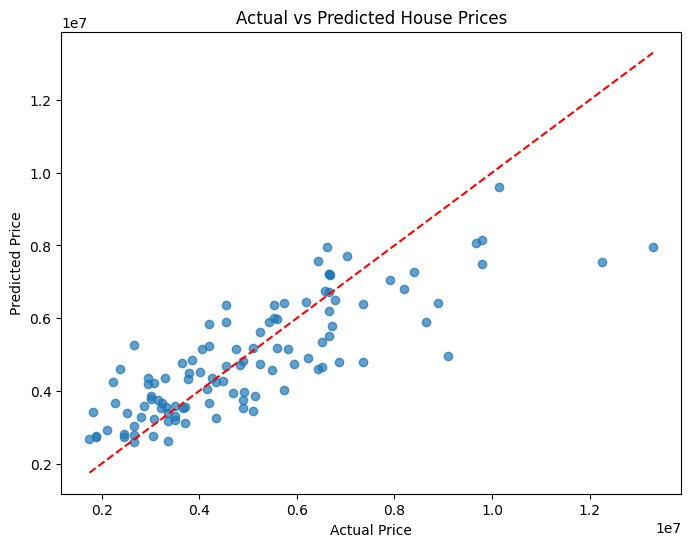

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

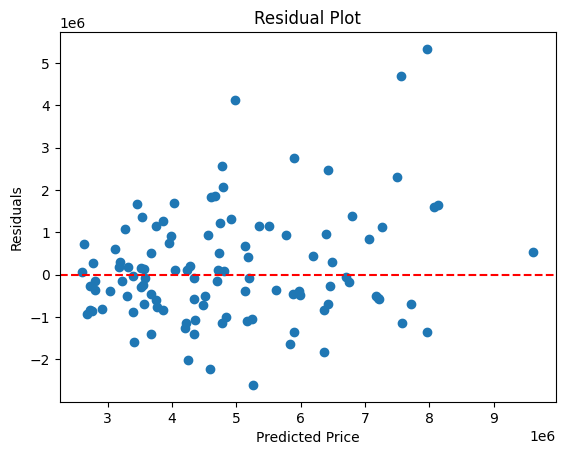

In [ ]:
residuals = y_test - y_pred # residual is the difference between the actual and the predicted values

plt.scatter(y_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

### Model Coefficients

In [22]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients = coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

print(coefficients)

                            Feature    Coefficient
8                   airconditioning  791426.735843
7                   hotwaterheating  684649.885339
10                         prefarea  629890.565313
2                         bathrooms  521879.027748
0                              area  519552.416340
6                          basement  390251.176181
4                          mainroad  367919.947680
3                           stories  349251.438906
5                         guestroom  231610.037176
9                           parking  192005.953667
1                          bedrooms   57349.559419
11  furnishingstatus_semi-furnished -126881.817585
12     furnishingstatus_unfurnished -413645.062228


#### Regression Coefficients Interpretation

The coefficients show how each feature affects the predicted house price while holding all other features constant.

- **Air conditioning, hot water heating, and location in a preferred area** have the strongest positive impact on house prices.
- **Bathrooms and house area** are among the most influential structural features.
- **Furnished houses** generally command higher prices than semi-furnished or unfurnished houses.
- The **number of bedrooms** contributes relatively little once area, bathrooms, and other features are already considered.


According to the linear regression model both the property size (area, bathrooms, stories) and amenities (air conditioning, basement, parking, preferred location) significantly impact house prices. Features related to comfort and location have a stronger impact on price than simply increasing the number of bedrooms.

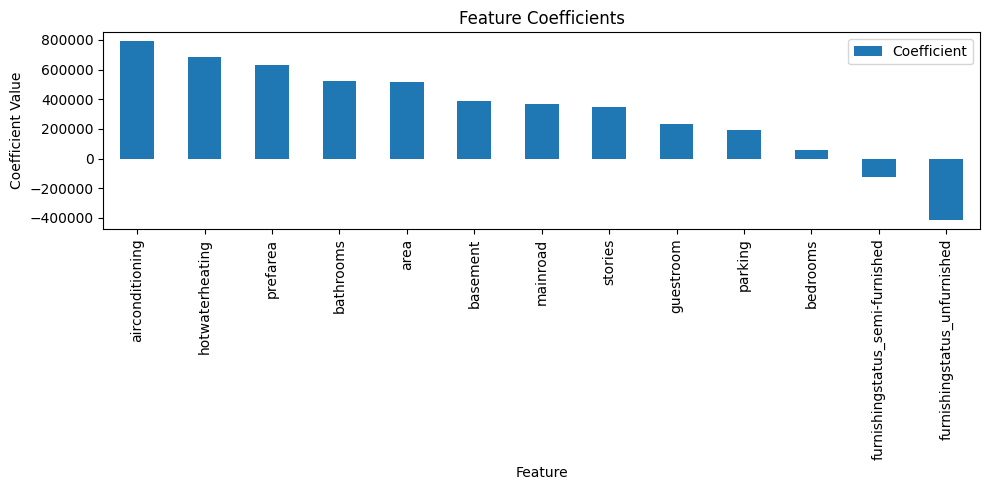

In [23]:
import matplotlib.pyplot as plt

coefficients.plot(
    x='Feature',
    y='Coefficient',
    kind='bar',
    figsize=(10,5)
)

plt.title("Feature Coefficients")
plt.ylabel("Coefficient Value")
plt.tight_layout()
plt.show()